In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # NOTE: use this to select GPU
import torch
from timm.models import create_model

import model.conv_segmenter_peft
import model.conv_segmenter
import model.mamba_segmenter
import utils as utils
from ref_dataset import get_transform_seg


DEVICE = torch.device("cuda")
SEED = 42
MODEL_NAME = "ReMamber_Conv_PEFT" # or "ReMamber_Conv"
CKPT_PATH = "pretrain/ReMamber_Conv.pth"
#CKPT_PATH = "outputs/checkpoint_model:330c832c.pth"
CKPT_PATH = "outputs/checkpoint_model:de3e9b2b.pth"
CKPT_PATH = "l_outputs/ReMamber_Conv_PEFT_dadapter/checkpoint_model:71ce0db5.pth"
# prepare model and transforms
demo_model, new_param = create_model(
    MODEL_NAME,
    img_size=480,
    model_size="base",
    use_adapters=False
)

checkpoint = torch.load(CKPT_PATH, map_location='cpu')
demo_model.load_state_dict(checkpoint['model'])
demo_model.to(DEVICE)
demo_model.eval()
transforms = get_transform_seg(size=(480,480), train=False)

/home/akula.ha/.conda/envs/refseg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


kwargs {'use_adapters': False}
Training the full decoder
False


RuntimeError: Error(s) in loading state_dict for ConvSegmentor_PEFT:
	Unexpected key(s) in state_dict: "decoder.adapters.0.down.weight", "decoder.adapters.0.down.bias", "decoder.adapters.0.d_moc.branch1.conv.weight", "decoder.adapters.0.d_moc.branch1.bn.weight", "decoder.adapters.0.d_moc.branch1.bn.bias", "decoder.adapters.0.d_moc.branch1.bn.running_mean", "decoder.adapters.0.d_moc.branch1.bn.running_var", "decoder.adapters.0.d_moc.branch1.bn.num_batches_tracked", "decoder.adapters.0.d_moc.branch2.conv.weight", "decoder.adapters.0.d_moc.branch2.bn.weight", "decoder.adapters.0.d_moc.branch2.bn.bias", "decoder.adapters.0.d_moc.branch2.bn.running_mean", "decoder.adapters.0.d_moc.branch2.bn.running_var", "decoder.adapters.0.d_moc.branch2.bn.num_batches_tracked", "decoder.adapters.0.d_moc.branch3.conv.weight", "decoder.adapters.0.d_moc.branch3.bn.weight", "decoder.adapters.0.d_moc.branch3.bn.bias", "decoder.adapters.0.d_moc.branch3.bn.running_mean", "decoder.adapters.0.d_moc.branch3.bn.runn

In [18]:
import argparse
from timm.scheduler import CosineLRScheduler


args = argparse.Namespace(
    lr           = 3e-4,     # “others” group
    lr_decoder   = 3e-4,
    lr_backbone  = 1e-4,
    lr_vssm      = 1e-4,
    weight_decay = 1e-4,
    decay_epochs = 13,
    min_lr=3e-7,
    warmup_epochs=3,
    warmup_lr=1e-7
)

optimizer = torch.optim.AdamW(
    [torch.nn.Parameter(torch.zeros(1, requires_grad=True))],
    lr=3.3e-5,
    weight_decay=1e-4
)


# ───────────────────────────────── 2. Re‑create the scheduler ─────────────────────────────────
# IMPORTANT: the constructor arguments *must* be identical to those used originally,
# otherwise the loaded state will not match.
scheduler = CosineLRScheduler(
    optimizer,
    t_initial=args.decay_epochs,         # 13 in your case
    lr_min=args.min_lr,                  # 3e‑7
    warmup_t=args.warmup_epochs,         # 2
    warmup_lr_init=args.warmup_lr,       # 1e‑6
    cycle_limit=1,
    t_in_epochs=True,                    # you step once per epoch
)

# ───────────────────────────────── 3. Load checkpoint ─────────────────────────────────

#optimizer.load_state_dict(checkpoint['optimizer'])
scheduler.load_state_dict(checkpoint['lr_scheduler'])   # ← this is the key line


In [21]:
print(scheduler.__dict__)

{'optimizer': AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 3.3e-05
    lr: 1e-07
    maximize: False
    weight_decay: 0.0001
), 'param_group_field': 'lr', '_initial_param_group_field': 'initial_lr', 'base_values': [3.3e-05, 3.3e-05, 1.65e-05, 1.65e-05], 'metric': None, 'noise_range_t': None, 'noise_pct': 0.67, 'noise_type': 'normal', 'noise_std': 1.0, 'noise_seed': 0, 't_initial': 50, 't_mul': 1.0, 'lr_min': 3e-07, 'decay_rate': 0.1, 'cycle_limit': 1, 'warmup_t': 2, 'warmup_lr_init': 1e-06, 'warmup_prefix': False, 't_in_epochs': True, 'warmup_steps': [1.6000000000000003e-05, 1.6000000000000003e-05, 7.75e-06, 7.75e-06]}


In [16]:
checkpoint['lr_scheduler']

{'param_group_field': 'lr',
 '_initial_param_group_field': 'initial_lr',
 'base_values': [3.3e-05, 3.3e-05, 1.65e-05, 1.65e-05],
 'metric': None,
 'noise_range_t': None,
 'noise_pct': 0.67,
 'noise_type': 'normal',
 'noise_std': 1.0,
 'noise_seed': 0,
 't_initial': 50,
 't_mul': 1.0,
 'lr_min': 3e-07,
 'decay_rate': 0.1,
 'cycle_limit': 1,
 'warmup_t': 2,
 'warmup_lr_init': 1e-06,
 'warmup_prefix': False,
 't_in_epochs': True,
 'warmup_steps': [1.6000000000000003e-05,
  1.6000000000000003e-05,
  7.75e-06,
  7.75e-06]}

In [13]:
scheduler

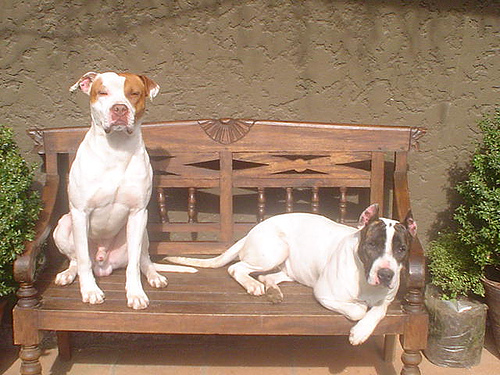

In [24]:
# read the image
from PIL import Image
input_img = Image.open("assets/demo_image.jpg")
input_img


In [39]:
# image transform and model inference
img = transforms(input_img, torch.zeros(1,480,480))[0].unsqueeze(0).to(DEVICE)
txt = "The left and right dog"
output = demo_model(img, [txt])
output.shape


torch.Size([1, 1, 480, 480])

Input text: The left and right dog


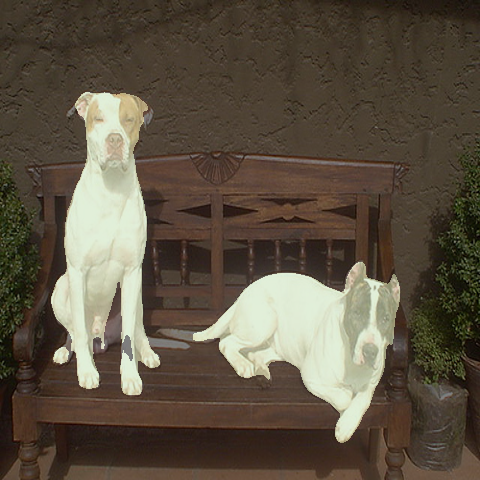

In [40]:
# show result
pred = (output.sigmoid().cpu().detach().squeeze() > 0.5).unsqueeze(-1)
color = torch.tensor([197,224,180]).unsqueeze(0)
pred_mask = Image.fromarray((pred*color).numpy().astype('uint8'))
print("Input text:", txt)
Image.blend(input_img.resize((480,480)), pred_mask, alpha=0.5)


In [1]:
!nvidia-smi

Sun Apr 20 02:10:02 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A6000               On  | 00000000:61:00.0 Off |                  Off |
| 30%   33C    P8              22W / 300W |      3MiB / 49140MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [6]:
checkpoint = torch.load(CKPT_PATH, map_location='cpu')

In [7]:
checkpoint.keys()

dict_keys(['model'])

In [5]:
from model.utils import create_optimizer
from timm.scheduler import create_scheduler

optimizer = create_optimizer(args, model_without_ddp, new_param)
lr_scheduler, _ = create_scheduler(args, optimizer)

NameError: name 'args' is not defined

In [2]:
a, b = demo_model.load_state_dict(checkpoint['model'], strict=False)

In [25]:
demo_model.backbone

ReMamber(
  (patch_embed): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Identity()
    (2): LayerNorm2d((64,), eps=1e-05, elementwise_affine=True)
    (3): Identity()
    (4): GELU(approximate='none')
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (6): Identity()
    (7): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): ModuleList(
    (0): Sequential(
      (blocks): Sequential(
        (0): VSSBlock(
          (norm): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
          (op): SS2D(
            (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
            (in_proj): Linear2d(in_features=128, out_features=256, bias=False)
            (act): SiLU()
            (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
            (out_act): Identity()
            (out_proj): Linear2d(in_features=256, out_featu

In [50]:
model.backbone.multimodal_blocks

ModuleList(
  (0): VSSLayer(
    (blocks): ModuleList(
      (0-1): 2 x VSSBlock(
        (ln_1): LayerNorm2d((128,), eps=1e-05, elementwise_affine=True)
        (self_attention): Twister(
          (ss2d): SS2D(
            (out_norm): LayerNorm2d((256,), eps=1e-05, elementwise_affine=True)
            (in_proj): Linear2d(in_features=384, out_features=256, bias=False)
            (act): SiLU()
            (conv2d): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=False)
            (out_act): Identity()
            (out_proj): Linear2d(in_features=256, out_features=128, bias=False)
            (dropout): Identity()
          )
          (ss1d): SS2D(
            (out_norm): LayerNorm2d((512,), eps=1e-05, elementwise_affine=True)
            (in_proj): Linear2d(in_features=256, out_features=1024, bias=False)
            (act): SiLU()
            (conv2d): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=512, bias=False)
    

In [29]:
m1 = demo_model

In [36]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # NOTE: use this to select GPU
import torch
from timm.models import create_model

import model.conv_segmenter_peft
import model.conv_segmenter
import model.mamba_segmenter
import utils as utils
from ref_dataset import get_transform_seg


DEVICE = torch.device("cuda")
SEED = 42
MODEL_NAME = "ReMamber_Conv" # "ReMamber_Mamba" or "ReMamber_Conv"
CKPT_PATH = "pretrain/vssm_base_0229_ckpt_epoch_237.pth"#"checkpoints/ReMamber_Mamba.pth"
CKPT_PATH = "pretrain/ReMamber_Conv.pth"
#CKPT_PATH = "outputs/checkpoint_model:330c832c.pth"
#CKPT_PATH = "outputs/checkpoint_model:de3e9b2b.pth"
# prepare model and transforms
demo_model, new_param = create_model(
    MODEL_NAME,
    img_size=480,
    model_size="base",
    use_adapters=True
)

checkpoint = torch.load(CKPT_PATH, map_location='cpu')
demo_model.load_state_dict(checkpoint['model'])
demo_model.to(DEVICE)
demo_model.eval()
transforms = get_transform_seg(size=(480,480), train=False)

kwargs {}


In [31]:
m2 = demo_model

In [38]:
# 0) Freeze absolutely everything
for param in model.parameters():
    param.requires_grad = False

# Now do your selective un‑freezing…
backbone = model.backbone

# # 1) freeze backbone in case decoder was part of model.parameters()
# for param in backbone.parameters():
#     param.requires_grad = False

# 2) Freeze the last VSS layer (initially wrote for unfreeze, left it as is)
last_idx = backbone.num_layers - 1
for param in backbone.layers[last_idx].parameters():
    param.requires_grad = False

# 3) Un‑freeze the corresponding multimodal block + text & fusion
for block in (
    backbone.multimodal_blocks[last_idx],
    backbone.text_guidencee[last_idx],
    backbone.local_text_fusion[last_idx],
):
    for param in block.parameters():
        param.requires_grad = False

for param in block.parameters():
    param.requires_grad = False
for param in backbone.multimodal_blocks[last_idx].blocks[-1].parameters():
    param.requires_grad = True

# 4) Un‑freeze the decoder head
for param in model.decoder.neck.parameters():
    param.requires_grad = True


In [2]:
def count_parameters(model: torch.nn.Module):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    return {
        "trainable": trainable,
        "non_trainable": non_trainable,
        "total": trainable + non_trainable
    }


In [34]:
count_parameters(m1)

{'trainable': 139226912, 'non_trainable': 123060480, 'total': 262287392}

In [35]:
count_parameters(m2)

{'trainable': 139226912, 'non_trainable': 123060480, 'total': 262287392}

In [6]:
(count_parameters(m1.backbone)['total'] - count_parameters(m2.backbone)['total'])/count_parameters(m2.backbone)['total']

0.05833981080813187

In [11]:
(count_parameters(m1.text_encoder)['total'] - count_parameters(m2.text_encoder)['total'])/count_parameters(m2.text_encoder)['total']

0.004792960339501357

In [14]:
(count_parameters(m1.decoder)['total'] - count_parameters(m2.decoder)['total'])/count_parameters(m2.decoder)['total']

0.37148803659005253

In [23]:
(count_parameters(m1)['total'] - count_parameters(m2)['total'])/count_parameters(m2)['total']

0.030282308919196952

In [16]:
count_parameters(m1.decoder)['total']

13007940

In [17]:
count_parameters(m2.decoder)['total']

9484545

TypeError: unsupported operand type(s) for -: 'dict' and 'dict'

In [37]:
count_parameters(model)

{'trainable': 15293441, 'non_trainable': 239284736, 'total': 254578177}

In [30]:
n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('number of params:', n_parameters)

number of params: 9484545


In [48]:
backbone.multimodal_blocks[last_idx],
    backbone.text_guidencee[last_idx],
    backbone.local_text_fusion[last_idx],

IndentationError: unexpected indent (26770960.py, line 2)

In [21]:
count_parameters(backbone.multimodal_blocks[last_idx].blocks[-1])

{'trainable': 9977344, 'non_trainable': 0, 'total': 9977344}

In [53]:
count_parameters(backbone.multimodal_blocks[last_idx])

TypeError: 'VSSLayer' object is not subscriptable

In [11]:
con = {}
con['decoder_adapter'] = True

In [19]:
model = demo_model

In [18]:
model = demo_model

#    for name, param in model.named_parameters():
# 1) Freeze absolutely everything in the backbone
for p in model.backbone.parameters():
    p.requires_grad = False

# 2) Un‐freeze the block adapters
for adapter in model.backbone.block_adapters:
    for p in adapter.parameters():
        p.requires_grad = True

# 3) Un‐freeze the image adapters
for adapter in model.backbone.image_adapters:
    for p in adapter.parameters():
        p.requires_grad = True

# 4) Un‐freeze the decoder head
for p in model.decoder.parameters():
    p.requires_grad = True


if con['decoder_adapter']:
    model.decoder.set_freeze_decoder(True)
    model.decoder.unfreeze_adapters()
    model.decoder.unfreeze_neck()
else:
    model.decoder.set_freeze_decoder(False)
    

AttributeError: 'ReMamber' object has no attribute 'block_adapters'

In [14]:
n_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('number of params:', n_parameters)

number of params: 132545025


In [15]:
#all_param1 = old.named_parameters()


In [6]:
config_dict = {'patch_size': 4,
 'in_chans': 3,
 'num_classes': 1000,
 'depths': [2, 2, 15, 2],
 'dims': [128, 256, 512, 1024],
 'ssm_d_state': 1,
 'ssm_ratio': 2.0,
 'ssm_rank_ratio': 2.0,
 'ssm_dt_rank': 'auto',
 'ssm_act_layer': 'silu',
 'ssm_conv': 3,
 'ssm_conv_bias': False,
 'ssm_drop_rate': 0.0,
 'ssm_init': 'v0',
 'forward_type': 'v4noz',
 'mlp_ratio': 4.0,
 'mlp_act_layer': 'gelu',
 'mlp_drop_rate': 0.0,
 'drop_path_rate': 0.1,
 'patch_norm': True,
 'norm_layer': 'ln2d',
 'downsample_version': 'v3',
 'patchembed_version': 'v2',
 'gmlp': False,
 'use_checkpoint': False}

In [4]:
from model.conv_segmenter_peft import ReMamber_PEFT
from model.conv_segmenter import ReMamber
from model.utils import load_ckpt

In [7]:
backbone = ReMamber(**config_dict)
backbone, ret = load_ckpt(backbone, "base")


In [16]:
all_param = demo_model.named_parameters()
text_backbone = []
visual_backbone = []
decoder = []
others = []
other_n = []
for n, p in all_param:
    if 'text_encoder' in n:
        text_backbone.append(n)
    elif 'decoder' in n:
        decoder.append(n)
    elif 'backbone' in n and ".".join(n.split(".")[1:]) not in visual_backbone:
        visual_backbone.append(n)
    else:
        others.append(n)


In [5]:
all_param = demo_model.named_parameters()
text_backbone = []
visual_backbone = []
decoder = []
others = []
other_n = []
for n, p in all_param:
    if 'text_encoder' in n:
        text_backbone.append(p)
    elif 'decoder' in n:
        decoder.append(p)
    elif 'backbone' in n and ".".join(n.split(".")[1:]) not in new_param:
        visual_backbone.append(p)
    else:
        others.append(p)
        other_n.append(n)
print(other_n)


['backbone.patch_embed.0.weight', 'backbone.patch_embed.0.bias', 'backbone.patch_embed.2.weight', 'backbone.patch_embed.2.bias', 'backbone.patch_embed.5.weight', 'backbone.patch_embed.5.bias', 'backbone.patch_embed.7.weight', 'backbone.patch_embed.7.bias', 'backbone.layers.0.blocks.0.norm.weight', 'backbone.layers.0.blocks.0.norm.bias', 'backbone.layers.0.blocks.0.op.x_proj_weight', 'backbone.layers.0.blocks.0.op.dt_projs_weight', 'backbone.layers.0.blocks.0.op.dt_projs_bias', 'backbone.layers.0.blocks.0.op.A_logs', 'backbone.layers.0.blocks.0.op.Ds', 'backbone.layers.0.blocks.0.op.out_norm.weight', 'backbone.layers.0.blocks.0.op.out_norm.bias', 'backbone.layers.0.blocks.0.op.in_proj.weight', 'backbone.layers.0.blocks.0.op.conv2d.weight', 'backbone.layers.0.blocks.0.op.out_proj.weight', 'backbone.layers.0.blocks.0.norm2.weight', 'backbone.layers.0.blocks.0.norm2.bias', 'backbone.layers.0.blocks.0.mlp.fc1.weight', 'backbone.layers.0.blocks.0.mlp.fc1.bias', 'backbone.layers.0.blocks.0.ml

In [10]:
visual_backbone

[]

In [9]:
new_param

['patch_embed.0.weight',
 'patch_embed.0.bias',
 'patch_embed.2.weight',
 'patch_embed.2.bias',
 'patch_embed.5.weight',
 'patch_embed.5.bias',
 'patch_embed.7.weight',
 'patch_embed.7.bias',
 'layers.0.blocks.0.norm.weight',
 'layers.0.blocks.0.norm.bias',
 'layers.0.blocks.0.op.x_proj_weight',
 'layers.0.blocks.0.op.dt_projs_weight',
 'layers.0.blocks.0.op.dt_projs_bias',
 'layers.0.blocks.0.op.A_logs',
 'layers.0.blocks.0.op.Ds',
 'layers.0.blocks.0.op.out_norm.weight',
 'layers.0.blocks.0.op.out_norm.bias',
 'layers.0.blocks.0.op.in_proj.weight',
 'layers.0.blocks.0.op.conv2d.weight',
 'layers.0.blocks.0.op.out_proj.weight',
 'layers.0.blocks.0.norm2.weight',
 'layers.0.blocks.0.norm2.bias',
 'layers.0.blocks.0.mlp.fc1.weight',
 'layers.0.blocks.0.mlp.fc1.bias',
 'layers.0.blocks.0.mlp.fc2.weight',
 'layers.0.blocks.0.mlp.fc2.bias',
 'layers.0.blocks.1.norm.weight',
 'layers.0.blocks.1.norm.bias',
 'layers.0.blocks.1.op.x_proj_weight',
 'layers.0.blocks.1.op.dt_projs_weight',
 'lay

In [4]:
visual_backbone

[]

In [17]:
others

[]

In [18]:
visual_backbone

['backbone.patch_embed.0.weight',
 'backbone.patch_embed.0.bias',
 'backbone.patch_embed.2.weight',
 'backbone.patch_embed.2.bias',
 'backbone.patch_embed.5.weight',
 'backbone.patch_embed.5.bias',
 'backbone.patch_embed.7.weight',
 'backbone.patch_embed.7.bias',
 'backbone.layers.0.blocks.0.norm.weight',
 'backbone.layers.0.blocks.0.norm.bias',
 'backbone.layers.0.blocks.0.op.x_proj_weight',
 'backbone.layers.0.blocks.0.op.dt_projs_weight',
 'backbone.layers.0.blocks.0.op.dt_projs_bias',
 'backbone.layers.0.blocks.0.op.A_logs',
 'backbone.layers.0.blocks.0.op.Ds',
 'backbone.layers.0.blocks.0.op.out_norm.weight',
 'backbone.layers.0.blocks.0.op.out_norm.bias',
 'backbone.layers.0.blocks.0.op.in_proj.weight',
 'backbone.layers.0.blocks.0.op.conv2d.weight',
 'backbone.layers.0.blocks.0.op.out_proj.weight',
 'backbone.layers.0.blocks.0.norm2.weight',
 'backbone.layers.0.blocks.0.norm2.bias',
 'backbone.layers.0.blocks.0.mlp.fc1.weight',
 'backbone.layers.0.blocks.0.mlp.fc1.bias',
 'backb

In [ ]:
for o in others[:20]:
    print(o, ".".join(o.split(".")[1:]))

In [ ]:
visual_backbone

In [ ]:
 ".".join(n.split(".")[1:])

In [ ]:
visual_backbone

In [ ]:
visual_backbone

In [ ]:
checkpoint = torch.load(CKPT_PATH, map_location='cpu')
demo_model.load_state_dict(checkpoint['model'], strict=False)
demo_model.to(DEVICE)
demo_model.eval()
transforms = get_transform_seg(size=(480,480), train=False)

In [ ]:
model = demo_model

In [ ]:
demo_model

In [ ]:
import torch

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPTextModel, CLIPTokenizerFast
from peft import LoraConfig, get_peft_model, TaskType
import torch
from model.utils import dice_loss, sigmoid_focal_loss
from model.base_segmenter_peft import get_text_encoder_weights

class BaseSegmenter_PEFT(nn.Module):
    def __init__(self, backbone, **kwargs):
        super().__init__()
        self.backbone = backbone
        self.decoder = None

        self.tokenizer = CLIPTokenizerFast.from_pretrained(
            "openai/clip-vit-large-patch14"
        )

        # — load base CLIP text encoder —
        base_text = CLIPTextModel.from_pretrained(
            "openai/clip-vit-large-patch14"
        )

        text_state = get_text_encoder_weights()
        base_text.load_state_dict(text_state, strict=True)

        # — configure LoRA —
        lora_cfg = LoraConfig(
            inference_mode=False,          # we’re fine‐tuning
            r=8,                           # LoRA rank
            lora_alpha=32,
            lora_dropout=0.1,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        )

        # — wrap with LoRA adapters (freezes base_text) —
        self.text_encoder = get_peft_model(base_text, lora_cfg)

    def forward(self, x, text, mask=None, **kwargs):
            # Tokenize input text
            encoding = self.tokenizer(
                text,
                padding='max_length',
                truncation=True,
                max_length=20,
                return_tensors='pt'
            )
            input_ids = encoding['input_ids'].to(x.device, non_blocking=True)
            attention_mask = encoding['attention_mask'].to(x.device, non_blocking=True)

            # Encode text with LoRA-adapted encoder
            #ret = self.text_encoder.base_model(
            #    input_ids=input_ids,
            #    attention_mask=attention_mask,
            #    output_hidden_states=False,
            #    return_dict=True
            #)
            ret = self.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=False,
                return_dict=True
            )
            l_feats = ret.last_hidden_state  # (B, N_l, C)
            l_feats = l_feats.permute(0, 2, 1)  # (B, C, N_l)
            l_mask = attention_mask.unsqueeze(-1)  # (B, N_l, 1)

            # Extract optional pooled output
            pooler_out = ret.pooler_output if hasattr(ret, "pooler_output") else None

            # Pass through backbone and decoder
            features = self.backbone(x, l_feats, l_mask, pooler_out=pooler_out)
            x_c1, x_c2, x_c3, x_c4 = features
            pred = self.decoder([x_c4, x_c3, x_c2, x_c1], l_feats, l_mask)
            pred = F.interpolate(pred, x.shape[-2:], mode='bilinear', align_corners=True)

            # Compute loss during training
            if self.training:
                loss = dice_loss(pred, mask) + sigmoid_focal_loss(pred, mask, alpha=-1, gamma=0)
                return pred.detach(), mask, loss
            else:
                return pred.detach()

In [ ]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.registry import register_model

#from model.base_segmenter import BaseSegmenter
#from .customized_model import ReMamber
from model.utils import load_ckpt, update_mamba_config
#from .dense_alignment import CrossAligner, DenseAligner, DenseMixtureOfConvolution


class Conv2d_BN(nn.Module):
    """Convolution with BN module."""
    def __init__(
        self,
        in_ch,
        out_ch,
        kernel_size=1,
        stride=1,
        pad=0,
        dilation=1,
        groups=1,
        bn_weight_init=1,
        norm_layer=nn.BatchNorm2d,
        act_layer=None,
    ):
        super().__init__()

        self.conv = torch.nn.Conv2d(in_ch,
                                    out_ch,
                                    kernel_size,
                                    stride,
                                    pad,
                                    dilation,
                                    groups,
                                    bias=False)
        self.bn = norm_layer(out_ch)
        torch.nn.init.constant_(self.bn.weight, bn_weight_init)
        torch.nn.init.constant_(self.bn.bias, 0)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Note that there is no bias due to BN
                fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(mean=0.0, std=np.sqrt(2.0 / fan_out))

        self.act_layer = act_layer() if act_layer is not None else nn.Identity()

    def forward(self, x):
        """foward function"""
        x = self.conv(x)
        x = self.bn(x)
        x = self.act_layer(x)

        return x


class ResBlock(nn.Module):
    """Residual block for convolutional local feature."""
    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        act_layer=nn.Hardswish,
        norm_layer=nn.BatchNorm2d,
    ):
        super().__init__()

        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.conv1 = Conv2d_BN(in_features,
                               hidden_features,
                               act_layer=act_layer)
        self.dwconv = nn.Conv2d(
            hidden_features,
            hidden_features,
            3,
            1,
            1,
            bias=False,
            groups=hidden_features,
        )
        self.norm = norm_layer(hidden_features)
        self.act = act_layer()
        self.conv2 = Conv2d_BN(hidden_features, out_features)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        """
        initialization
        """
        if isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()
        elif isinstance(m, nn.BatchNorm2d):
            m.weight.data.fill_(1)
            m.bias.data.zero_()

    def forward(self, x):
        """foward function"""
        identity = x
        feat = self.conv1(x)
        feat = self.dwconv(feat)
        feat = self.norm(feat)
        feat = self.act(feat)
        feat = self.conv2(feat)
        return feat
        # return identity + feat

class ConvDecoderAdapter(nn.Module):
    def __init__(self, in_dim, reduction_factor=4):
        super().__init__()
        hidden_dim = in_dim // reduction_factor
        self.down = nn.Conv2d(in_dim, hidden_dim, 1)
        self.d_moc = DenseMixtureOfConvolution(hidden_dim)
        self.up = nn.Conv2d(hidden_dim, in_dim, 1)
        self.act = nn.ReLU()
        
    def forward(self, x):
        residual = x
        x = self.down(x)
        x = self.act(x)
        x = self.d_moc(x)
        x = self.up(x)
        return x + residual

class ConvDecoder_PEFT(nn.Module):
    """Modified ConvDecoder with adapters"""
    def __init__(self, in_dim, **kwargs) -> None:
        super().__init__()
        self.in_dim = [in_dim*8, in_dim*4, in_dim*2, in_dim]
        self.hidden_dim = in_dim*4

        self.mixer3 = ResBlock(in_dim*8, out_features=self.hidden_dim)
        self.mixer2 = ResBlock(in_dim*4+self.hidden_dim, out_features=self.hidden_dim)
        self.mixer1 = ResBlock(in_dim*2+self.hidden_dim, out_features=self.hidden_dim)

        # Add decoder adapters
        self.adapter3 = ConvDecoderAdapter(self.hidden_dim)
        self.adapter2 = ConvDecoderAdapter(self.hidden_dim)
        self.adapter1 = ConvDecoderAdapter(self.hidden_dim)
        #print("creating adapters")
        self.neck = nn.Sequential(
            nn.Conv2d(self.hidden_dim+in_dim, self.hidden_dim, 3, padding=1),
            nn.BatchNorm2d(self.hidden_dim),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(self.hidden_dim, self.hidden_dim, 3, padding=1),
            nn.BatchNorm2d(self.hidden_dim),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(self.hidden_dim, 1, 3, padding=1)
        )
        
        # Add neck adapter
        self.neck_adapter = ConvDecoderAdapter(self.hidden_dim)
    
    def forward(self, x, *args):
        out0, out1, out2, out3 = x
        out = self.mixer3(out0)
        # Apply adapter
        out = out + self.adapter3(out)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)
        
        out = self.mixer2(torch.cat([out, out1], dim=1))
        # Apply adapter
        out = out + self.adapter2(out)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)
        
        out = self.mixer1(torch.cat([out, out2], dim=1))
        # Apply adapter
        out = out + self.adapter1(out)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)

        # Process first part of neck
        tmp = torch.cat([out, out3], dim=1)
        out = self.neck[0](tmp)  # Conv
        out = self.neck[1](out)  # BN
        out = self.neck[2](out)  # ReLU
        
        # Apply neck adapter
        out = out + self.neck_adapter(out)
        
        # Process remaining layers
        for layer in self.neck[3:]:
            out = layer(out)

        return out

class ConvSegmentor_PEFT(BaseSegmenter_PEFT):
    def __init__(self, backbone, img_size=256, patch_size=4, embed_dim=256, **kwargs):
        super().__init__(backbone)
        #print("kwargs", kwargs)
        res = img_size // patch_size
        self.decoder = ConvDecoder_PEFT(in_dim=embed_dim, resolution=res)


#@register_model
def ReMamber_Conv_PEFT(img_size, model_size="base", **kwargs):
    # This function remains unchanged
    config_dict = update_mamba_config(model_size)
    backbone = ReMamber_PEFT(**config_dict)
    backbone, ret = load_ckpt(backbone, model_size)
    model = ConvSegmentor_PEFT(backbone, img_size=img_size, embed_dim=config_dict['dims'][0], patch_size=config_dict['patch_size'])
    return model, ret[0]

In [ ]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.registry import register_model

class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class DenseMixtureOfConvolution(nn.Module):
    """
    Dense Mixture of Convolutions (D-MoC) core:
      - 1×1 branch
      - 3×3 branch (dense: sees input + branch1)
      - 5×5 branch (dense: sees input + branch1 + branch2)
      - concat branches + add input residual
    """
    def __init__(self, in_channels):
        super().__init__()
        # split channels so sum equals in_channels
        ch1 = in_channels // 2
        ch2 = in_channels // 4
        ch3 = in_channels - ch1 - ch2

        self.branch1 = BasicConv2d(in_channels, ch1, kernel_size=1)
        self.branch2 = BasicConv2d(in_channels + ch1, ch2, kernel_size=3, padding=1)
        self.branch3 = BasicConv2d(in_channels + ch1 + ch2, ch3, kernel_size=5, padding=2)

    def forward(self, x):
        # x: (B, C, H, W)
        b1 = self.branch1(x)
        b2 = self.branch2(torch.cat([x, b1], dim=1))
        b3 = self.branch3(torch.cat([x, b1, b2], dim=1))
        out = torch.cat([b1, b2, b3], dim=1)
        # residual add (channels match in_channels)
        return out + x


In [ ]:
class CrossTwister(nn.Module):
    """
    Mamba Twister fusion that projects both image and text into a shared embed_dim,
    then applies global token + local fusion inside a VSSLayer Twister block.
    """
    def __init__(self, img_dim, txt_dim, embed_dim, cfg):
        super().__init__()
        # store config
        self.cfg = cfg
        # 1) project image channels -> embed_dim via 1x1 conv
        # image is already projected outside, img_dim = embed_dim
        self.img_proj = nn.Identity() #nn.Conv2d(img_dim, embed_dim, kernel_size=1)
        # 2) project text embeddings -> embed_dim via linear
        self.txt_proj = nn.Linear(txt_dim, embed_dim)
        # ReMamber norm & act lookups
        _NORMLAYERS = dict(ln=nn.LayerNorm, ln2d=LayerNorm2d, bn=nn.BatchNorm2d)
        _ACTLAYERS  = dict(silu=nn.SiLU, gelu=nn.GELU, relu=nn.ReLU, sigmoid=nn.Sigmoid)
        norm_layer    = _NORMLAYERS[cfg['norm_layer'].lower()]
        ssm_act_layer = _ACTLAYERS[cfg['ssm_act_layer'].lower()]
        # 3) one-layer VSS Twister at embed_dim
        self.vss = VSSLayer(
            dim             = embed_dim,
            depth           = 1,
            use_checkpoint  = cfg['use_checkpoint'],
            norm_layer      = norm_layer,
            ssm_act_layer   = ssm_act_layer,
            downsample      = None,
            channel_first   = cfg['channel_first'],
            # SSM params from config
            ssm_d_state     = cfg['ssm_d_state'],
            ssm_ratio       = 1, #cfg['ssm_ratio'],
            ssm_dt_rank     = 1, #cfg['ssm_dt_rank'],
            ssm_conv        = cfg['ssm_conv'],
            ssm_conv_bias   = cfg['ssm_conv_bias'],
            ssm_drop_rate   = cfg['ssm_drop_rate'],
            ssm_init        = cfg['ssm_init'],
            forward_type    = cfg['forward_type'],
            # dummy MLP args
            mlp_ratio       = cfg['mlp_ratio'],
            mlp_act_layer   = cfg['mlp_act_layer'],
            mlp_drop_rate   = cfg['mlp_drop_rate'],
            gmlp            = cfg['gmlp'],
            forward_coremm  = 'Twister',
        )
        # global guidance MLP mapped from embed_dim (post txt_proj)
        #self.global_mlp = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.ReLU())
        # using projected text output as input for global mlp
        self.global_mlp = nn.Sequential(nn.Identity(), nn.ReLU())
        # local fusion expects embed_dim for text and visual dims
        hidden_dim = 128
        self.local_fuser = ImageTextCorr(
            visual_dim = embed_dim,
            text_dim   = embed_dim,
            hidden_dim = hidden_dim,
            out_dim    = embed_dim,
        )

    def forward(self, img, l_feat, l_mask, pooler_out=None):
        """
        img:       [B, img_dim, H, W]
        l_feat:    [B, txt_dim, L] or [B, L, txt_dim]
        l_mask:    [B, L]
        pooler_out:[B, txt_dim] opt override
        """
        B, _, H, W = img.shape
        # 1) project image -> embed_dim
        img_e = self.img_proj(img)  # [B, embed_dim, H, W]
        # 2) ensure l_feat in [B, L, txt_dim]
        if l_feat.dim()==3 and l_feat.shape[1]!=l_feat.shape[-1]:
            l_feat = l_feat.transpose(1,2)
        # 3) project each text token -> embed_dim
        txt_seq = self.txt_proj(l_feat)  # [B, L, embed_dim]
        # override pooling via projected pooler_out if given
        if pooler_out is not None:
            pool = self.txt_proj(pooler_out)  # [B, embed_dim]
        else:
            pool = txt_seq[:,0]               # token0
        # 4) global cond -> broadcast to spatial
        g = self.global_mlp(pool)           # [B, embed_dim]
        global_cond = g.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, H, W)
        # 5) local fusion map from embedded img & txt
        local = self.local_fuser(img_e, txt_seq.transpose(1,2), l_mask)
        local_cond = einops.rearrange(local, 'b h w c -> b c h w', h=H)
        # 6) Twister on (img_e, global_cond, local_cond)
        fused, _ = self.vss((img_e, global_cond, local_cond), txt_seq, l_mask)
        # fused[0] has shape [B, embed_dim, H, W]
        return fused[0]


# ============== DenseAligner (uses CrossTwister) ================
class DenseAligner(nn.Module):
    """
    Adapter that downsamples image to a reduced dim, applies D-MoC,
    fuses via CrossTwister, then upsamples back to original dim.
    """
    def __init__(self, dim, text_dim=768, reduction_factor=8, cfg=None):
        super().__init__()
        self.cfg = cfg
        # 1) image normalization + down-projection
        self.norm = nn.LayerNorm(dim)
        reduced = dim // reduction_factor #128
        self.img_down = nn.Linear(dim, reduced)
        self.act = nn.ReLU()    
        # 2) dense mixture of convolution at reduced dim
        self.d_moc = DenseMixtureOfConvolution(reduced)
        # 3) cross-modal Twister fusion at reduced dim
        self.cross_twister = CrossTwister(
            img_dim   = reduced,
            txt_dim   = text_dim,
            embed_dim = reduced,
            cfg       = cfg,
        )
        # 4) up-projection back to original dim
        self.img_up = nn.Linear(reduced, dim)
        self.alpha = nn.Parameter(torch.tensor(1.0))  # Initialize with 1.0 (no effect initially)


    def forward(self, x, l_feat, l_mask, pooler_out=None):
        B, C, H, W = x.shape
        # 1) Norm and down-project image
        xi = einops.rearrange(x, 'b c h w -> b h w c')
        xi = self.norm(xi)
        xi = einops.rearrange(xi, 'b h w c -> b (h w) c')
        xi = self.img_down(xi)
        xi = self.act(xi)
        xi = einops.rearrange(xi, 'b (h w) c -> b c h w', h=H, w=W)
        # 2) Dense mixture of convolutions
        xdm = self.d_moc(xi)
        # 3) Cross-modal fusion via Twister
        xf = self.cross_twister(xdm, l_feat, l_mask, pooler_out)
        # 4) Residual at reduced scale
        xf = xf + xi
        # 5) Up-project back and final residual
        xu = einops.rearrange(xf, 'b c h w -> b (h w) c')
        xu = self.img_up(xu)
        xu = einops.rearrange(xu, 'b (h w) c -> b c h w', h=H, w=W)
        return x + self.alpha * xu


In [ ]:
import torch
import torch.nn as nn
import einops

class ImageAdapter(nn.Module):
    """
    Lightweight image adapter:
    - Normalizes and downsamples the image.
    - Applies a Dense Mixture of Convolutions.
    - Residual connection at reduced scale.
    - Upsamples back and scales with a learnable alpha.
    """
    def __init__(self, dim, reduction_factor=4):
        super().__init__()
        reduced = dim // reduction_factor

        self.norm = nn.LayerNorm(dim)
        self.img_down = nn.Linear(dim, reduced)
        self.act = nn.ReLU()

        self.d_moc = DenseMixtureOfConvolution(reduced)

        self.img_up = nn.Linear(reduced, dim)

        # Learnable residual scale
        self.alpha = nn.Parameter(torch.tensor(1.0))

    def forward(self, x, l_feat=None, l_mask=None, pooler_out=None):
        """
        Args:
            x: [B, C, H, W] input image features
            (l_feat, l_mask, pooler_out): unused in this variant
        Returns:
            [B, C, H, W] scaled residual output
        """
        B, C, H, W = x.shape

        # 1. Normalize and down-project
        xi = einops.rearrange(x, 'b c h w -> b h w c')
        xi = self.norm(xi)
        xi = einops.rearrange(xi, 'b h w c -> b (h w) c')
        xi = self.img_down(xi)  # [B, H*W, reduced]
        xinit = xi
        xi = self.act(xi)
        xi = einops.rearrange(xi, 'b (h w) c -> b c h w', h=H, w=W)

        # 2. Apply DenseMixtureOfConvolution
        xdm = self.d_moc(xi)  # [B, reduced, H, W]

        # 3. Residual at reduced scale
        xf = xdm + einops.rearrange(xinit, 'b (h w) c -> b c h w', h=H, w=W)

        # 4. Up-project to original dim
        xu = einops.rearrange(xf, 'b c h w -> b (h w) c')
        xu = self.img_up(xu)
        xu = einops.rearrange(xu, 'b (h w) c -> b c h w', h=H, w=W)

        # 5. Return scaled residual output
        return self.alpha * xu


In [ ]:

from timm.models.layers import DropPath

DropPath.__repr__ = lambda self: f"timm.DropPath({self.drop_prob})"

import einops

from vmamba_model.vmamba import SS2D, VSSM, LayerNorm2d, Linear2d

from model.utils import ImageTextCorr

class Twister(nn.Module):
    def __init__(
            self,         
            # basic dims ===========
            d_model=96,
            d_state=16,
            ssm_ratio=2.0,
            dt_rank="auto",
            act_layer=nn.SiLU,
            # dwconv ===============
            d_conv=3, # < 2 means no conv 
            conv_bias=True,
            # ======================
            dropout=0.0,
            bias=False,
            # dt init ==============
            dt_min=0.001,
            dt_max=0.1,
            dt_init="random",
            dt_scale=1.0,
            dt_init_floor=1e-4,
            initialize="v0",
            # ======================
            forward_type="v2",
            channel_first=False,
            # ======================
            input_res=32,
            **kwargs,
        ):
        super().__init__()
        self.input_res = input_res
        self.ss2d = SS2D(d_model, d_state, ssm_ratio, dt_rank, act_layer, d_conv, conv_bias, dropout, bias, dt_min, dt_max, dt_init, dt_scale, dt_init_floor, initialize, forward_type, channel_first, **kwargs)
        self.ss2d.in_proj = Linear2d(d_model * 3, self.ss2d.in_proj.weight.shape[0], bias=bias)
        self.input_res = min(input_res, 16)
        forward_type_1d = "v052d"
        self.ss1d = SS2D(self.input_res**2, d_state, ssm_ratio, dt_rank, act_layer, d_conv, conv_bias, dropout, bias, dt_min, dt_max, dt_init, dt_scale, dt_init_floor, initialize, forward_type_1d, channel_first, **kwargs)
    
    def forward(self, x: torch.Tensor, **kwargs):
        img, global_cond, local_cond = x
        B, C, H, W = img.shape
        if global_cond is not None:
            x = torch.cat([img, global_cond, local_cond], dim=1) # b l 3c
        else:
            x = torch.cat([img, local_cond], dim=-1)
        x_prepaired = x
        x_mix = F.interpolate(x, size=(self.input_res,self.input_res), mode='bilinear')
        x_mix = x_mix.view(B, -1, self.input_res**2)
        x_mix = x_mix.permute(0, 2, 1).unsqueeze(-2).contiguous() # b, hw, 1, c
        x_mix = self.ss1d(x_mix)
        x_mix = x_mix.squeeze(-2).permute(0, 2, 1).contiguous() # b, c, hw
        x_mix = F.interpolate(x_mix.view(B,-1,self.input_res,self.input_res), size=(H,W), mode='bilinear')

        x = x_mix + x_prepaired
        
        out = self.ss2d(x)

        out = [out, global_cond, local_cond]
        return out

class VSSBlock(nn.Module):
    def __init__(
        self,
        forward_coremm='SS2D',
        **kwargs,
    ):
        super().__init__()
        norm_layer = kwargs['norm_layer']
        dim = kwargs['dim']
        drop_path = kwargs['drop_path']
        self.ln_1 = norm_layer(dim)
        self.forward_coremm = forward_coremm
        if not forward_coremm:
            raise
        elif forward_coremm == 'SS2D':
            self.self_attention = SS2D(
                d_model=dim,
                d_state=kwargs['ssm_d_state'],
                dt_rank=kwargs['ssm_dt_rank'],
                act_layer=kwargs['ssm_act_layer'],
                d_conv=kwargs['ssm_conv'],
                conv_bias=kwargs['ssm_conv_bias'],
                dropout=kwargs['ssm_drop_rate'],
                initialize=kwargs['ssm_init'],
                **kwargs,
            )
        elif forward_coremm == 'Twister':
            self.self_attention = Twister(
                d_model=dim,
                d_state=kwargs['ssm_d_state'],
                ssm_ratio=kwargs['ssm_ratio'],
                dt_rank=kwargs['ssm_dt_rank'],
                act_layer=kwargs['ssm_act_layer'],
                d_conv=kwargs['ssm_conv'],
                conv_bias=kwargs['ssm_conv_bias'],
                dropout=kwargs['ssm_drop_rate'],
                initialize=kwargs['ssm_init'],
                forward_type=kwargs['forward_type'],
                channel_first=kwargs['channel_first'],
            )
        else:
            raise
        self.drop_path = DropPath(drop_path)

    def forward(self, input: torch.Tensor):
        if isinstance(input, torch.Tensor):
            out = self.ln_1(input)
            out = self.self_attention(out)
            out = input + self.drop_path(out)
            x = out
        else:
            # input should be a list (img and global / local conditions)
            out = [self.ln_1(i) if i is not None else None for i in input]
            out = self.self_attention(out)
            out = [i + self.drop_path(o) if i is not None else None for i, o in zip(input, out)]
            x = out
        return x


class VSSLayer(nn.Module):
    """ A basic Swin Transformer layer for one stage.
    Args:
        dim (int): Number of input channels.
        depth (int): Number of blocks.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float | tuple[float], optional): Stochastic depth rate. Default: 0.0
        norm_layer (nn.Module, optional): Normalization layer. Default: nn.LayerNorm
        downsample (nn.Module | None, optional): Downsample layer at the end of the layer. Default: None
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
    """

    def __init__(
        self, 
        depth,
        downsample=None,
        forward_coremm="Twister",
        **kwargs,
    ):
        super().__init__()
        # dim = kwargs['dim']
        drop_path = 0.
        dim = kwargs['dim']
        use_checkpoint = kwargs['use_checkpoint']
        norm_layer = kwargs['norm_layer']


        self.dim = dim
        self.use_checkpoint = use_checkpoint

        self.blocks = nn.ModuleList([
            VSSBlock(
                forward_coremm=forward_coremm,
                drop_path=drop_path[i] if isinstance(drop_path, list) else drop_path,
                **kwargs,
            )
            for i in range(depth)])
        
        if True: # is this really applied? Yes, but been overriden later in VSSM!
            def _init_weights(module: nn.Module):
                for name, p in module.named_parameters():
                    if name in ["out_proj.weight"]:
                        p = p.clone().detach_() # fake init, just to keep the seed ....
                        nn.init.kaiming_uniform_(p, a=math.sqrt(5))
            self.apply(_init_weights)

        if downsample is not None:
            self.downsample = downsample(dim=dim, norm_layer=norm_layer, channel_first=kwargs['channel_first'])
        else:
            self.downsample = None

    def forward(self, x, l_feat, l_mask):
        for blk in self.blocks:
            if self.use_checkpoint:
                x = checkpoint.checkpoint(blk, x)
            else:
                x = blk(x)
        # x: b w h c
        inner = x
        if self.downsample is not None:
            x = self.downsample(x)

        return x, inner



In [ ]:
from vmamba_model.vmamba import VSSBlock as OriginalVSSBlock

class ReMamber_PEFT(VSSM):
    """ReMamber with PEFT-style adapters over VSSBlocks and full multimodal pipeline"""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.classifier = None
        self.VSSBlockType = OriginalVSSBlock

        dims = kwargs['dims']
        use_checkpoint = kwargs['use_checkpoint']
        norm_layer_key = kwargs['norm_layer']

        self.block_adapters = nn.ModuleList()
        self.text_guidencee = nn.ModuleList()
        self.local_text_fusion = nn.ModuleList()
        self.image_adapters = nn.ModuleList()
        self.multimodal_blocks = nn.ModuleList()

        # Normalization & activation layer maps
        _NORMLAYERS = dict(ln=nn.LayerNorm, ln2d=LayerNorm2d, bn=nn.BatchNorm2d)
        norm_layer = _NORMLAYERS[norm_layer_key.lower()]
        _ACTLAYERS = dict(silu=nn.SiLU, gelu=nn.GELU, relu=nn.ReLU, sigmoid=nn.Sigmoid)
        ssm_act_layer = _ACTLAYERS[kwargs['ssm_act_layer'].lower()]

        for i_layer in range(self.num_layers):
            # Build multimodal VSS layer (your Twister-augmented version)
            layer = VSSLayer(
                dim=dims[i_layer],
                depth=2,
                use_checkpoint=use_checkpoint,
                norm_layer=norm_layer,
                ssm_act_layer=ssm_act_layer,
                downsample=None,
                channel_first=self.channel_first,
                # ===== SSM params
                ssm_d_state=kwargs['ssm_d_state'],
                ssm_ratio=kwargs['ssm_ratio'],
                ssm_dt_rank=kwargs['ssm_dt_rank'],
                ssm_conv=kwargs['ssm_conv'],
                ssm_conv_bias=kwargs['ssm_conv_bias'],
                ssm_drop_rate=kwargs['ssm_drop_rate'],
                ssm_init=kwargs['ssm_init'],
                forward_type=kwargs['forward_type'],
                # ===== MLP
                mlp_ratio=kwargs['mlp_ratio'],
                mlp_act_layer=kwargs['mlp_act_layer'],
                mlp_drop_rate=kwargs['mlp_drop_rate'],
                gmlp=kwargs['gmlp'],
                forward_coremm='Twister',
            )
            self.multimodal_blocks.append(layer)

            # Adapter list over each VSSBlock inside this layer
            adapter_list = nn.ModuleList()
            vss_layer = self.layers[i_layer]
            
            for j, block in enumerate(vss_layer.blocks):
                if isinstance(block, self.VSSBlockType) and j % 2 == 0:  # Apply to every other block
                    dim = block.norm.normalized_shape[0]
                    adapter = DenseAligner(dim=dim, cfg={**kwargs, "channel_first": self.channel_first})
                else:
                    adapter = nn.Identity()  # Or use a no-op wrapper if needed
                adapter_list.append(adapter)

            self.block_adapters.append(adapter_list)

            # Text -> channel-wise guidence MLP
            self.text_guidencee.append(
                nn.Sequential(nn.Linear(768, dims[i_layer]), nn.ReLU())
            )

            # Spatial multimodal fuser
            self.local_text_fusion.append(
                ImageTextCorr(
                    visual_dim=dims[i_layer],
                    text_dim=768,
                    hidden_dim=512,
                    out_dim=dims[i_layer],
                )
            )

            # Final adapter over fused image feature
            self.image_adapters.append(ImageAdapter(dims[i_layer]))

    def forward_layer(self, x, layer, adapters, l_feat, l_mask, pooler_out):
        blocks = layer[0]
        for block, adapter in zip(blocks, adapters):
            x_in = x
            block_out = block(x_in)
            #x = adapter(block_out, l_feat, l_mask, pooler_out)  # Adapter adds residual inside
            if isinstance(adapter, nn.Identity):
                adapter_feats = x_in  # no-op
            else:
                adapter_feats = adapter(x_in, l_feat, l_mask, pooler_out)

            x = block_out + (adapter_feats - x_in)  

        inner = x  # Before downsampling
        if len(layer) > 1:
            x = layer[1](x)  # Downsample
        return x, inner

    def forward(self, x, l_feat, l_mask, pooler_out=None):
        x = self.patch_embed(x)
        outs = []

        for i, layer in enumerate(self.layers):
            x, inner = self.forward_layer(x, layer, self.block_adapters[i], l_feat, l_mask, pooler_out)
            _, c, h, w = inner.shape
            out = inner

            pooling_text = l_feat[..., 0] if pooler_out is None else pooler_out
            text_guidence = self.text_guidencee[i](pooling_text)
            text_guidence = einops.repeat(text_guidence, "b c -> b c h w", h=h, w=w)

            local_text = self.local_text_fusion[i](out, l_feat, l_mask)
            local_text = einops.rearrange(local_text, 'b h w c -> b c h w', h=h)

            mm_input = (out, text_guidence, local_text)
            ret = self.multimodal_blocks[i](mm_input, None, None)[0]
            img_feat = ret[0]

            adapter_out = self.image_adapters[i](out)
            img_feat = img_feat + adapter_out

            if len(layer) > 1:
                x = layer[1](img_feat)  # Downsample final fused feature
            else:
                x = img_feat

            outs.append(img_feat)

        return outs


In [ ]:
config = {
    "batch_size": 2,
    "epochs": 50,
    "model": "ReMamber_Conv",
    "pretrain_path": "./pretrain",
    "input_size": 480,
    "drop": 0.0,
    "drop_path": 0.1,
    "model_ema": False,
    "model_ema_decay": 0.9999,
    "model_ema_force_cpu": False,
    "opt": "adamw",
    "opt_eps": 1e-08,
    "opt_betas": None,
    "clip_grad": None,
    "momentum": 0.9,
    "weight_decay": 0.0001,
    "sched": "cosine",
    "lr": 5e-05,
    "lr_decoder": 5e-05,
    "lr_backbone": 2.5e-05,
    "lr_vssm": 2.5e-05,
    "warmup_lr": 1e-06,
    "min_lr": 1e-06,
    "decay_epochs": 30,
    "warmup_epochs": 0,
    "cooldown_epochs": 10,
    "patience_epochs": 10,
    "decay_rate": 0.1,
    "train_mode": True,
    "finetune": "test_training/best_checkpoint.pth",
    "data_path": "./ref_dataset/data",
    "data_set": "refzom", #"refcoco",
    "output_dir": "./test_training",
    "device": "cuda",
    "seed": 0,
    "resume": "",
    "start_epoch": 0,
    "eval": False,
    "dist_eval": False,
    "num_workers": 8,
    "pin_mem": True,
    "distributed": True,
    "world_size": 1,
    "dist_url": "env://",
    "if_amp": True,
    "debug_mode": True,
    "local_rank": 0,
    "use_dense_aligner": True,
    "use_text_adapter": True,
    #"da_layers": "1,3,5,7,9,11",
    #"ta_layers": "1,3,5,7,9,11",
    "da_dim": 128,
    "ta_dim": 64,
    "rank": 0,
    "gpu": 0,
    "dist_backend": "nccl"
}


In [ ]:
# read the image
from PIL import Image
input_img = Image.open("assets/demo_image.jpg")
input_img

In [ ]:
model, _ = ReMamber_Conv_PEFT(config["input_size"], model_size="base", **config)


In [ ]:
decoder_params = sum(p.numel() for p in model.decoder.parameters() if p.requires_grad)
print(f"Decoder Parameters: {decoder_params}")


In [ ]:
from types import SimpleNamespace

# Convert dictionary to namespace
args = config_obj = SimpleNamespace(**config)

In [ ]:
DEVICE = torch.device("cuda")
SEED = 42
# MODEL_NAME = "ReMamber_Conv" # "ReMamber_Mamba" or "ReMamber_Conv"
# CKPT_PATH = "pretrain/vssm_base_0229_ckpt_epoch_237.pth"#"checkpoints/ReMamber_Mamba.pth"
CKPT_PATH = "pretrain/ReMamber_Conv.pth"

# prepare model and transforms
# demo_model, new_param = create_model(
#     MODEL_NAME,
#     img_size=480,
#     model_size="base",
# )

checkpoint = torch.load(CKPT_PATH, map_location='cpu')
a, b = model.load_state_dict(checkpoint['model'], strict = False)
#model.to(DEVICE)
#demo_model.eval()
from ref_dataset import get_transform_seg

transforms = get_transform_seg(size=(480,480), train=False)

In [ ]:
# CKPT_PATH = "pretrain/ReMamber_Conv.pth"

# checkpoint = torch.load(CKPT_PATH, map_location='cpu')
# model.load_state_dict(checkpoint['model'], strict = False)
model.to(DEVICE)
model.eval()
# # image transform and model inference
img = transforms(input_img, torch.zeros(1,480,480))[0].unsqueeze(0).to(DEVICE)
txt = "dogs"
output = model(img, [txt])
output.shape

In [ ]:
100 * (count_parameters(model.backbone.block_adapters)+count_parameters(model.backbone.image_adapters))/count_parameters(model_without_adapters.backbone)

In [ ]:
# show result
pred = (output.sigmoid().cpu().detach().squeeze() > 0.5).unsqueeze(-1)
color = torch.tensor([197,224,180]).unsqueeze(0)
pred_mask = Image.fromarray((pred*color).numpy().astype('uint8'))
print("Input text:", txt)
Image.blend(input_img.resize((480,480)), pred_mask, alpha=0.5)

In [ ]:
import torch.nn as nn

In [ ]:
def count_parameters(model: nn.Module, only_trainable: bool = False) -> int:
    """
    Returns the total number of parameters in `model`.
    If only_trainable=True, only counts those with `requires_grad=True`.
    """
    params = model.parameters()
    if only_trainable:
        params = filter(lambda p: p.requires_grad, params)
    return sum(p.numel() for p in params)


In [ ]:
count_parameters(model.decoder, True)

In [ ]:
count_parameters(model.backbone)

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # NOTE: use this to select GPU
import torch
from timm.models import create_model

import model.conv_segmenter
import model.mamba_segmenter
import utils as utils
from ref_dataset import get_transform_seg


DEVICE = torch.device("cuda")
SEED = 42
MODEL_NAME = "ReMamber_Conv" # "ReMamber_Mamba" or "ReMamber_Conv"
CKPT_PATH = "pretrain/vssm_base_0229_ckpt_epoch_237.pth"#"checkpoints/ReMamber_Mamba.pth"
CKPT_PATH = "pretrain/ReMamber_Conv.pth"

# prepare model and transforms
demo_model, new_param = create_model(
    MODEL_NAME,
    img_size=480,
    model_size="base",
)

checkpoint = torch.load(CKPT_PATH, map_location='cpu')
demo_model.load_state_dict(checkpoint['model'])
demo_model.to(DEVICE)
demo_model.eval()
transforms = get_transform_seg(size=(480,480), train=False)

In [ ]:
count_parameters(demo_model.backbone)

In [ ]:
model

In [ ]:
(count_parameters(model.text_encoder)-count_parameters(demo_model.text_encoder))

In [ ]:
model.text_encoder

In [ ]:
demo_model.text_encoder

In [ ]:
count_parameters(model.text_encoder)

In [ ]:
count_parameters(demo_model.text_encoder)

In [ ]:
model_without_adapters = demo_model

In [ ]:
100 * (count_parameters(model.backbone.block_adapters)+count_parameters(model.backbone.image_adapters))/count_parameters(model_without_adapters.backbone)

In [ ]:
count_parameters(model.backbone.image_adapters)

In [ ]:
model